# P02 - Global-mel y ventana temporal 1024

Este notebook registra dos cambios que si aportaron despues de P01:

- `globalmel`: normalizar cada banda mel con media y desvio global aprendidos en `train_curated`.
- `f1024`: usar una ventana temporal mas larga (`128 x 1024`) para darle mas contexto a la rama temporal.

La idea no es repetir P01, sino explicar que cambia en la representacion y por que esos cambios terminaron entrando al mejor blend.


## Imports y configuracion


In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ModuleNotFoundError:
    display = print

ROOT = Path.cwd()
if ROOT.name == '02_preprocesamiento':
    ROOT = ROOT.parent
DATA_DIR = ROOT / 'data'
RESULTS_DIR = ROOT / '02_preprocesamiento' / 'results'
FIG_DIR = RESULTS_DIR / 'figures'
INVESTIGATION = ROOT / 'investigation'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(INVESTIGATION))

pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 220)
plt.style.use('default')
plt.rcParams.update({
    'figure.figsize': (9, 4.8),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

from scripts.fat2019.features import read_wav_mono, log_mel_spectrogram
from numpy.lib.format import read_magic, _read_array_header


def npz_array_headers(path: Path) -> pd.DataFrame:
    rows = []
    with zipfile.ZipFile(path) as zf:
        for info in zf.infolist():
            if not info.filename.endswith('.npy'):
                continue
            with zf.open(info) as f:
                version = read_magic(f)
                shape, fortran_order, dtype = _read_array_header(f, version)
            rows.append({
                'array': info.filename.replace('.npy', ''),
                'shape': str(shape),
                'dtype': str(dtype),
                'compressed_mb': round(info.compress_size / 1024**2, 2),
            })
    return pd.DataFrame(rows)


def crop_or_pad_time(x: np.ndarray, frames: int, fill_value: float | None = None) -> np.ndarray:
    if x.shape[1] >= frames:
        return x[:, :frames]
    if fill_value is None:
        fill_value = float(x.min())
    pad_width = frames - x.shape[1]
    return np.pad(x, ((0, 0), (0, pad_width)), mode='constant', constant_values=fill_value)

print(f'FIG_DIR={FIG_DIR.relative_to(ROOT)}')


FIG_DIR=02_preprocesamiento/results/figures


## 1. Que cambia respecto a P01

P01 ya guarda una imagen log-mel `128 x 512`. P02 no cambia la idea de usar espectrogramas como imagen, sino dos detalles de preprocesamiento:

1. `globalmel`: cada banda mel se centra y escala con estadisticas globales del train. Esto hace que las bandas queden en escalas mas comparables.
2. `f1024`: duplica la ventana temporal. En vez de darle a la red 512 frames, le da 1024 frames para capturar eventos mas largos o separados en el tiempo.


In [2]:
p02_changes = pd.DataFrame([
    {
        'variant': 'P01_f512',
        'shape_per_audio': '128 x 512',
        'normalization': 'normalizacion original/local del cache',
        'why': 'baseline CNN sobre imagen log-mel',
    },
    {
        'variant': 'P02_globalmel_f512',
        'shape_per_audio': '128 x 512',
        'normalization': 'media y desvio global por banda mel',
        'why': 'estabilizar escala entre bandas',
    },
    {
        'variant': 'P02_f1024',
        'shape_per_audio': '128 x 1024',
        'normalization': 'misma idea de imagen, mas contexto temporal',
        'why': 'capturar eventos mas largos/separados',
    },
])
display(p02_changes)
p02_changes.to_csv(RESULTS_DIR / 'P02_changes_summary.csv', index=False)


,variant,shape_per_audio,normalization,why
0,P01_f512,128 x 512,normalizacion original/local del cache,baseline CNN sobre imagen log-mel
1,P02_globalmel_f512,128 x 512,media y desvio global por banda mel,estabilizar escala entre bandas
2,P02_f1024,128 x 1024,"misma idea de imagen, mas contexto temporal",capturar eventos mas largos/separados


## 2. Archivos generados y forma de los tensores

Esta verificacion es liviana: lee el encabezado del `.npz` sin cargar todo el tensor grande en memoria. Sirve para confirmar que existen las variantes promovidas y que tienen la forma esperada.


In [3]:
caches = {
    'curated_f512_globalmel': DATA_DIR / 'curated_logmel_image_m128_f512_globalmel.npz',
    'test_f512_globalmel': DATA_DIR / 'test_logmel_image_m128_f512_globalmel.npz',
    'curated_f1024': DATA_DIR / 'curated_logmel_image_m128_f1024.npz',
    'test_f1024': DATA_DIR / 'test_logmel_image_m128_f1024.npz',
}
summary = pd.concat([
    npz_array_headers(path).assign(cache=name, path=str(path.relative_to(ROOT)))
    for name, path in caches.items()
], ignore_index=True)
display(summary[['cache', 'array', 'shape', 'dtype', 'compressed_mb']])
summary.to_csv(RESULTS_DIR / 'P02_globalmel_f1024_summary.csv', index=False)


,cache,array,shape,dtype,compressed_mb
0,curated_f512_globalmel,x,"(4964, 128, 512)",float16,338.78
1,curated_f512_globalmel,fnames,"(4964,)",<U12,0.03
2,curated_f512_globalmel,normalization,(),<U10,0.00
3,curated_f512_globalmel,global_mean,"(128,)",float32,0.00
4,curated_f512_globalmel,global_std,"(128,)",float32,0.00
5,test_f512_globalmel,x,"(3361, 128, 512)",float16,280.87
6,test_f512_globalmel,fnames,"(3361,)",<U12,0.02
7,test_f512_globalmel,normalization,(),<U10,0.00
8,test_f512_globalmel,global_mean,"(128,)",float32,0.00
9,test_f512_globalmel,global_std,"(128,)",float32,0.00


## 3. Que hace `globalmel`

El cache `globalmel` guarda `global_mean` y `global_std`: una media y un desvio para cada una de las 128 bandas mel. La normalizacion transforma cada banda aproximadamente asi:

```text
valor_normalizado = (valor_original - media_global_de_la_banda) / std_global_de_la_banda
```

Esto evita que algunas bandas dominen solo por escala, y vuelve mas estable la entrada para la red.


,mel_band,global_mean,global_std
count,128.0000,128.0000,128.0000
mean,63.5000,-11.4043,21.2167
std,37.0945,4.4506,0.4601
min,0.0000,-25.5093,20.5606
25%,31.7500,-13.4782,20.9903
50%,63.5000,-10.5119,21.1244
75%,95.2500,-8.1187,21.3063
max,127.0000,-5.3923,23.3842


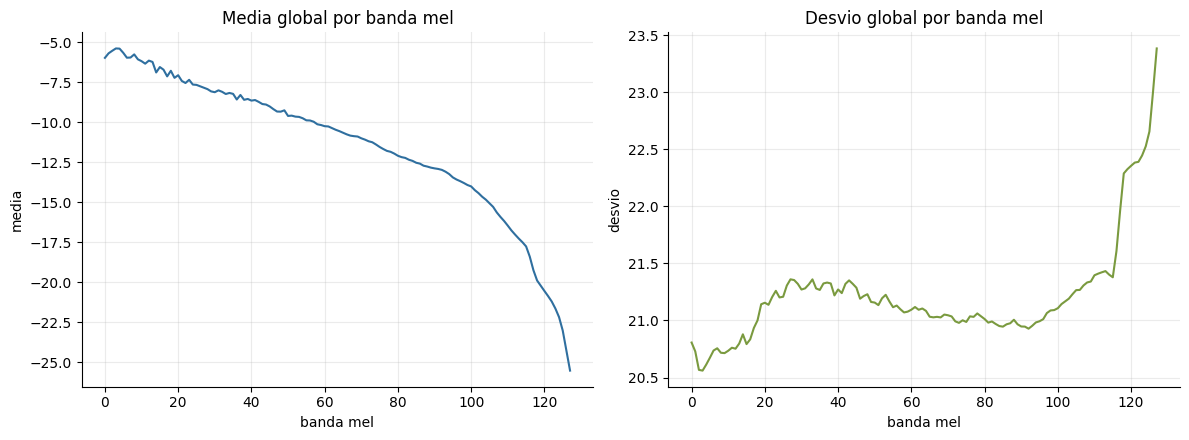

In [4]:
with np.load(DATA_DIR / 'curated_logmel_image_m128_f512_globalmel.npz', allow_pickle=True) as data:
    global_mean = data['global_mean'].astype(np.float32)
    global_std = data['global_std'].astype(np.float32)

normalization_stats = pd.DataFrame({
    'mel_band': np.arange(len(global_mean)),
    'global_mean': global_mean,
    'global_std': global_std,
})
display(normalization_stats.describe().round(4))
normalization_stats.to_csv(RESULTS_DIR / 'P02_globalmel_normalization_stats.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(normalization_stats['mel_band'], normalization_stats['global_mean'], color='#2f6f9f')
axes[0].set_title('Media global por banda mel')
axes[0].set_xlabel('banda mel')
axes[0].set_ylabel('media')

axes[1].plot(normalization_stats['mel_band'], normalization_stats['global_std'], color='#7a9a3f')
axes[1].set_title('Desvio global por banda mel')
axes[1].set_xlabel('banda mel')
axes[1].set_ylabel('desvio')
fig.tight_layout()
fig.savefig(FIG_DIR / 'P02_globalmel_mean_std.png', dpi=140, bbox_inches='tight')
plt.show()


## 4. Ejemplo visual: antes y despues de globalmel

Sobre un audio real, la normalizacion no cambia la estructura temporal del espectrograma: cambia la escala por banda. Las manchas siguen en el mismo lugar, pero los valores quedan centrados respecto al comportamiento global del train.


,fname,labels,raw_logmel_shape,f512_shape,globalmel_shape
0,0006ae4e.wav,Bark,"(128, 605)","(128, 512)","(128, 512)"


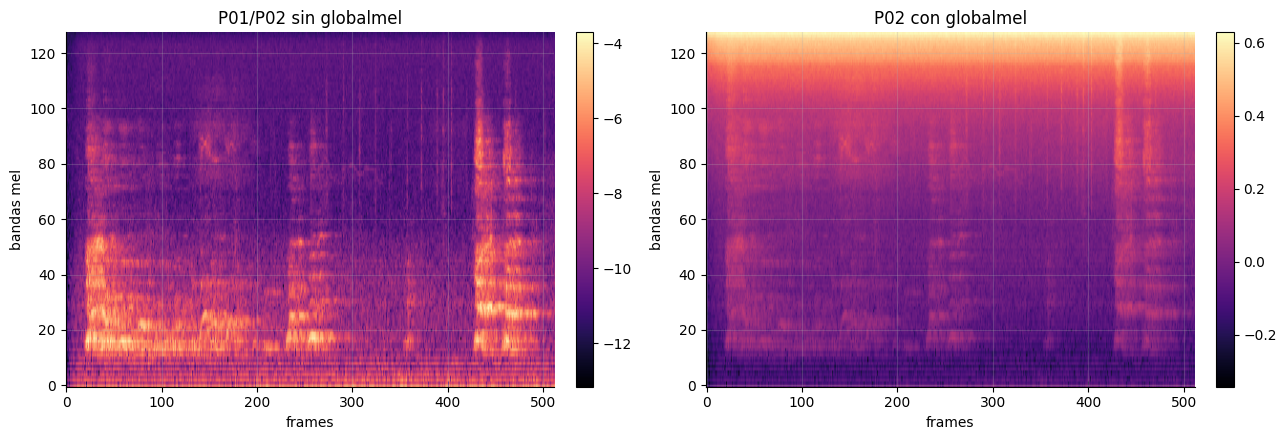

In [5]:
curated = pd.read_csv(DATA_DIR / 'train_curated.csv')
row = curated.iloc[0]
sample_rate, waveform = read_wav_mono(str(DATA_DIR / row['fname']))
logmel = log_mel_spectrogram(
    waveform,
    sample_rate=sample_rate,
    n_fft=1024,
    hop_length=512,
    n_mels=128,
    fmin=20.0,
    fmax=sample_rate / 2,
)
logmel_512 = crop_or_pad_time(logmel, 512)
logmel_512_global = (logmel_512 - global_mean[:, None]) / np.maximum(global_std[:, None], 1e-6)

display(pd.DataFrame([{
    'fname': row['fname'],
    'labels': row['labels'],
    'raw_logmel_shape': str(logmel.shape),
    'f512_shape': str(logmel_512.shape),
    'globalmel_shape': str(logmel_512_global.shape),
}]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
im0 = axes[0].imshow(logmel_512, origin='lower', aspect='auto', cmap='magma')
axes[0].set_title('P01/P02 sin globalmel')
axes[0].set_xlabel('frames')
axes[0].set_ylabel('bandas mel')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(logmel_512_global, origin='lower', aspect='auto', cmap='magma')
axes[1].set_title('P02 con globalmel')
axes[1].set_xlabel('frames')
axes[1].set_ylabel('bandas mel')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(FIG_DIR / 'P02_globalmel_before_after.png', dpi=140, bbox_inches='tight')
plt.show()


## 5. Que cambia con `frames=1024`

`f1024` no agrega mas bandas de frecuencia: sigue usando 128 bandas mel. Lo que cambia es el ancho temporal. La red ve el doble de frames, entonces puede observar mas contexto antes de comprimir la informacion.


,variant,shape,time_frames,mel_bands
0,f512,"(128, 512)",512,128
1,f1024,"(128, 1024)",1024,128


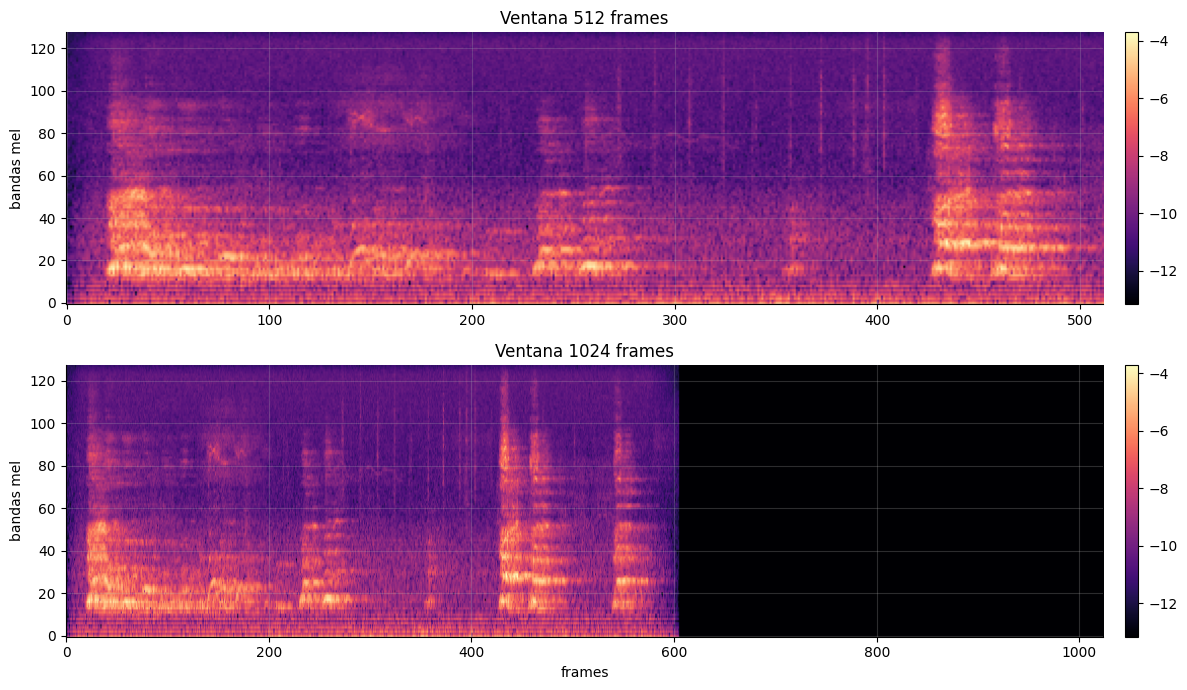

In [6]:
logmel_1024 = crop_or_pad_time(logmel, 1024)
shape_compare = pd.DataFrame([
    {'variant': 'f512', 'shape': str(logmel_512.shape), 'time_frames': logmel_512.shape[1], 'mel_bands': logmel_512.shape[0]},
    {'variant': 'f1024', 'shape': str(logmel_1024.shape), 'time_frames': logmel_1024.shape[1], 'mel_bands': logmel_1024.shape[0]},
])
display(shape_compare)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)
im0 = axes[0].imshow(logmel_512, origin='lower', aspect='auto', cmap='magma')
axes[0].set_title('Ventana 512 frames')
axes[0].set_ylabel('bandas mel')
fig.colorbar(im0, ax=axes[0], fraction=0.025, pad=0.02)

im1 = axes[1].imshow(logmel_1024, origin='lower', aspect='auto', cmap='magma')
axes[1].set_title('Ventana 1024 frames')
axes[1].set_xlabel('frames')
axes[1].set_ylabel('bandas mel')
fig.colorbar(im1, ax=axes[1], fraction=0.025, pad=0.02)
fig.tight_layout()
fig.savefig(FIG_DIR / 'P02_f512_vs_f1024.png', dpi=140, bbox_inches='tight')
plt.show()


## 6. Evidencia de la ronda nueva

La comparacion importante no es P02 se ve mas lindo, sino si mejora contra la referencia temporal previa. Los resultados vienen de `investigation/results/theory_supported_experiments_2026_06_29.md`.


,candidate,change,private_lb,decision,delta_vs_reference
3,current475_globalmel200_se125_f1024_200,globalmel + SE + f1024,0.67025,historical_best_expanded,0.01097
2,current550_globalmel250_f1024_200,globalmel + f1024 sin SE,0.66996,keep,0.01068
1,current645_globalmel_sep_temporal_full355,agrega globalmel,0.66561,keep,0.00633
0,current835_sep_temporal_full165,referencia previa temporal,0.65928,baseline,0.00000
4,current835_sep_temporal_tta1024_full165,TTA multicrop,0.65835,discard,-0.00093


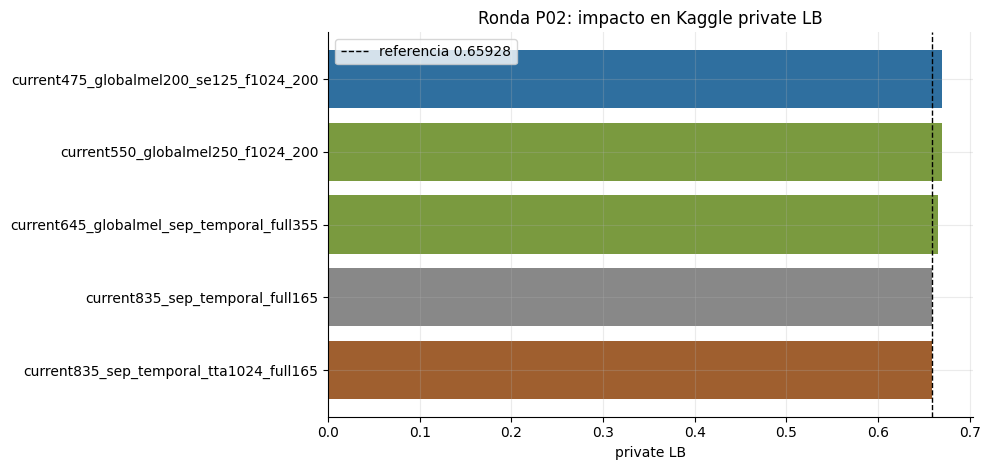

In [7]:
evidence = pd.DataFrame([
    {'candidate': 'current835_sep_temporal_full165', 'change': 'referencia previa temporal', 'private_lb': 0.65928, 'decision': 'baseline'},
    {'candidate': 'current645_globalmel_sep_temporal_full355', 'change': 'agrega globalmel', 'private_lb': 0.66561, 'decision': 'keep'},
    {'candidate': 'current550_globalmel250_f1024_200', 'change': 'globalmel + f1024 sin SE', 'private_lb': 0.66996, 'decision': 'keep'},
    {'candidate': 'current475_globalmel200_se125_f1024_200', 'change': 'globalmel + SE + f1024', 'private_lb': 0.67025, 'decision': 'historical_best_expanded'},
    {'candidate': 'current835_sep_temporal_tta1024_full165', 'change': 'TTA multicrop', 'private_lb': 0.65835, 'decision': 'discard'},
])
evidence['delta_vs_reference'] = evidence['private_lb'] - 0.65928
evidence_sorted = evidence.sort_values('private_lb', ascending=False)
display(evidence_sorted)
evidence.to_csv(RESULTS_DIR / 'P02_globalmel_f1024_evidence.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 4.8))
colors = evidence_sorted['decision'].map({
    'historical_best_expanded': '#2f6f9f',
    'keep': '#7a9a3f',
    'baseline': '#888888',
    'discard': '#9f5f2f',
}).fillna('#666666')
ax.barh(evidence_sorted['candidate'], evidence_sorted['private_lb'], color=colors)
ax.axvline(0.65928, color='black', linestyle='--', linewidth=1, label='referencia 0.65928')
ax.set_title('Ronda P02: impacto en Kaggle private LB')
ax.set_xlabel('private LB')
ax.invert_yaxis()
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'P02_evidence_private_lb.png', dpi=140, bbox_inches='tight')
plt.show()


## Decision

- `globalmel` queda promovido porque mejora la referencia temporal de `0.65928` a `0.66561`.
- `f1024` queda promovido cuando el modelo se entrena para esa ventana; no es solo cambiar el recorte en inferencia.
- TTA multi-crop no se promueve porque bajo contra la referencia.
- La mejor variante no reemplaza todo lo anterior: entra como componente del ensemble final con `current + globalmel + SE + f1024`.
